In [35]:
import warnings; warnings.simplefilter('ignore')
import csv
import matplotlib.pyplot as plt 
import numpy as np 

In [36]:
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]
    
    return inputs, outputs

import os

crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
print('in:  ', inputs[:5])
print('out: ', outputs[:5])

in:   [1.61646318435669, 1.48238301277161, 1.480633020401, 1.56497955322266, 1.44357192516327]
out:  [7.53700017929077, 7.52199983596802, 7.50400018692017, 7.49399995803833, 7.4689998626709]


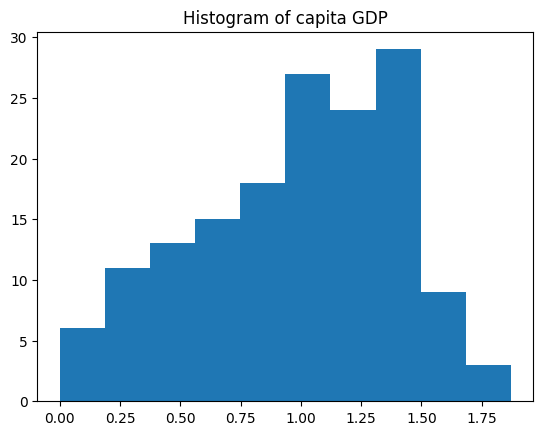

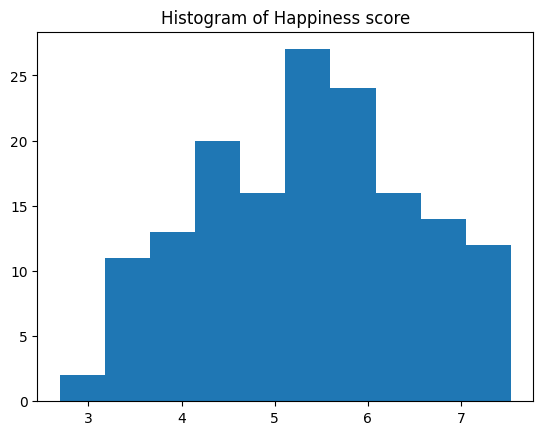

In [37]:
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, "capita GDP")
plotDataHistogram(outputs, "Happiness score")

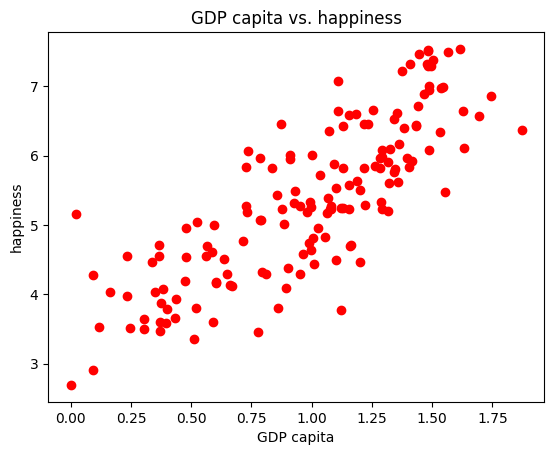

In [38]:
plt.plot(inputs, outputs, 'ro') 
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.title('GDP capita vs. happiness')
plt.show()

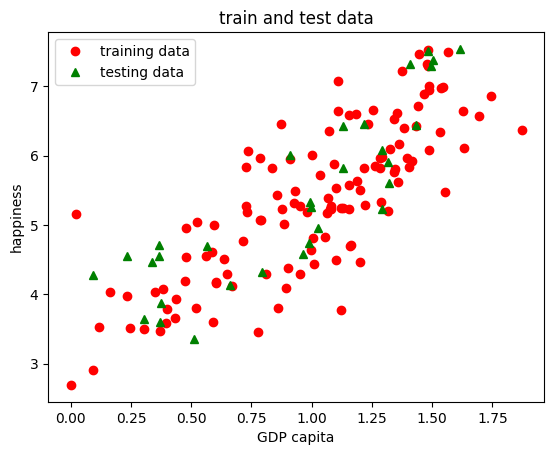

In [39]:
np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   
plt.plot(testInputs, testOutputs, 'g^', label = 'testing data')     
plt.title('train and test data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [40]:
xx = [[el] for el in trainInputs]

# from sklearn import linear_model
# regressor = linear_model.SGDRegressor(alpha = 0.01, max_iter = 100)
# regressor.fit(xx, trainOutputs)
# w0, w1 = regressor.intercept_[0], regressor.coef_[0]
# print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

# from SGD import MySGDRegression
# regressor = MySGDRegression()

from sklearn import linear_model
regressor = linear_model.SGDRegressor(alpha = 0.01, max_iter = 100)
for epoch in range(1000):
    regressor.partial_fit(xx, trainOutputs)
w0, w1 = regressor.intercept_[0], regressor.coef_[0]
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

# from BGD import MyBGDRegression 
# regressor = MyBGDRegression()
# regressor.fit(xx, trainOutputs)
# w0, w1 = regressor.intercept_, regressor.coef_[0]
# print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

the learnt model: f(x) =  3.320855441355561  +  2.030086007816736  * x


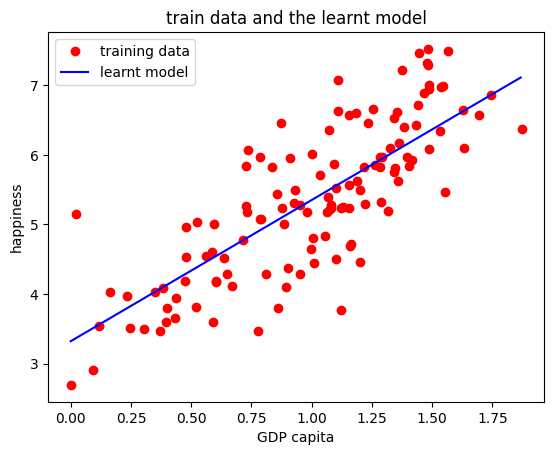

In [41]:
noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')  
plt.plot(xref, yref, 'b-', label = 'learnt model')                  
plt.title('train data and the learnt model')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

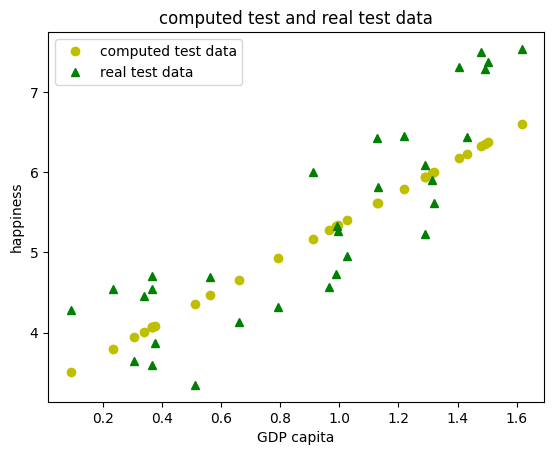

In [42]:
computedTestOutputs = regressor.predict([[x] for x in testInputs])
plt.plot(testInputs, computedTestOutputs, 'yo', label = 'computed test data')  #computed test data are plotted yellow red and circle sign
plt.plot(testInputs, testOutputs, 'g^', label = 'real test data')  #real test data are plotted by green triangles
plt.title('computed test and real test data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [43]:
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)
print('prediction error (manual): ', error)

from sklearn.metrics import mean_squared_error

error = mean_squared_error(testOutputs, computedTestOutputs)
print('prediction error (tool):  ', error)

prediction error (manual):  0.4237704781580827
prediction error (tool):   0.4237704781580827


In [44]:
import pandas as pd

path = "data/breast+cancer+wisconsin+diagnostic/wdbc.data"

df = pd.read_csv(
path,
header=None,
usecols=[1, 2, 3],
names=["diagnosis", "radius", "texture"]
)

df["label"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df[["radius", "texture"]].values
y = df["label"].values

print(df.head())

  diagnosis  radius  texture  label
0         M   17.99    10.38      1
1         M   20.57    17.77      1
2         M   19.69    21.25      1
3         M   11.42    20.38      1
4         M   20.29    14.34      1


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sklearn_classifier = LogisticRegression(random_state=42)
sklearn_classifier.fit(X_train_scaled, y_train)

y_pred_sklearn = sklearn_classifier.predict(X_test_scaled)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Acuratetea clasificatorului (scikit-learn): {acc_sklearn:.2f}")

# Textura=10, Raza=18. Ordinea este [raza, textura]
new_lesion = np.array([[18, 10]])
new_lesion_scaled = scaler.transform(new_lesion)

prediction_sklearn_raw = sklearn_classifier.predict(new_lesion_scaled)
prediction_sklearn_label = "Maligna" if prediction_sklearn_raw[0] == 1 else "Benigna"

print(f"\nLeziunea cu raza=18 si textura=10 este clasificata (scikit-learn) ca: {prediction_sklearn_label}\n\n")

from LR import MyLogisticRegression

my_classifier = MyLogisticRegression()
my_classifier.fit(X_train_scaled, y_train, learningRate=0.01, noEpochs=1000)

y_pred_my = my_classifier.predict(X_test_scaled)
acc_my = accuracy_score(y_test, y_pred_my)
print(f"Acuratetea clasificatorului (MyLogisticRegression): {acc_my:.2f}")

prediction_my_raw = my_classifier.predict(new_lesion_scaled)
prediction_my_label = "Maligna" if prediction_my_raw[0] == 1 else "Benigna"

print(f"\nLeziunea cu raza=18 si textura=10 este clasificata (MyLogisticRegression) ca: {prediction_my_label}")

Acuratetea clasificatorului (scikit-learn): 0.90

Leziunea cu raza=18 si textura=10 este clasificata (scikit-learn) ca: Maligna


Acuratetea clasificatorului (MyLogisticRegression): 0.85

Leziunea cu raza=18 si textura=10 este clasificata (MyLogisticRegression) ca: Maligna


Aria de sub curba ROC (AUC): 0.97



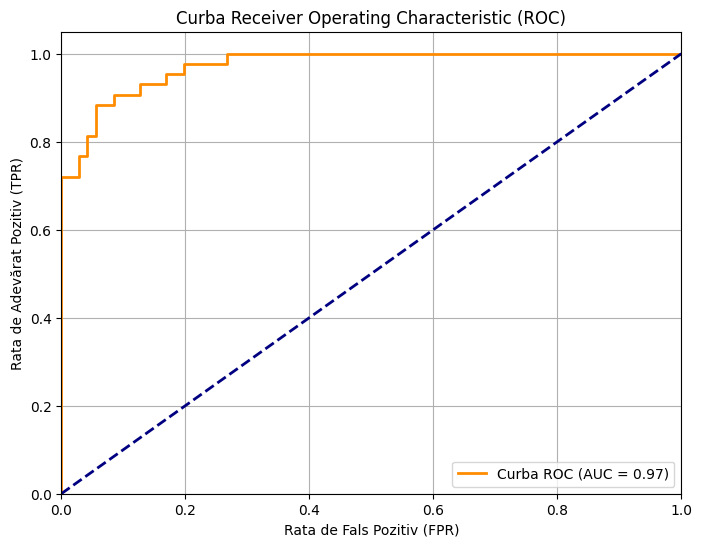

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = sklearn_classifier.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Aria de sub curba ROC (AUC): {auc:.2f}\n")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curba ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Linia aleatorie
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Rata de Fals Pozitiv (FPR)')
plt.ylabel('Rata de Adevărat Pozitiv (TPR)')
plt.title('Curba Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [27]:
path = "data/iris/iris.data"

df = pd.read_csv(
path,
header=None,
usecols=[0, 1, 2, 3, 4],
names=["sepal length", "sepal width", "petal length", "petal width", "class"]
)

X = df[["sepal length", "sepal width", "petal length", "petal width"]].values
y_str = df["class"].values
print(df.head())

   sepal length  sepal width  petal length  petal width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [ ]:
le = LabelEncoder()
y = le.fit_transform(y_str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Acuratețea modelului pe setul de test: {acc:.2f}\n")

# Caracteristici: [sepal length, sepal width, petal length, petal width]
new_flower = np.array([[5.35, 3.85, 1.25, 0.4]])

new_flower_scaled = scaler.transform(new_flower)

prediction_numeric = classifier.predict(new_flower_scaled)

species_name = le.inverse_transform(prediction_numeric)

print(f"Specia prezisă pentru noua floare este: {species_name[0]}")

Acuratețea modelului pe setul de test: 1.00

Specia prezisă pentru noua floare este: Iris-setosa


In [32]:
my_classifiers = {}
unique_classes = np.unique(y_train)

for cls in unique_classes:
    print(f"Antrenare clasificator pentru clasa {cls} vs. Restul...")
    
    y_train_binary = np.where(y_train == cls, 1, 0)
    
    classifier = MyLogisticRegression()
    classifier.fit(X_train_scaled, y_train_binary, learningRate=0.01, noEpochs=1000) 
    
    my_classifiers[cls] = classifier

scores = {}
for cls, classifier in my_classifiers.items():
    score = classifier.predict(new_flower_scaled) 
    scores[cls] = score[0]

predicted_class = max(scores, key=scores.get)

predicted_species_name = le.inverse_transform([predicted_class])

print(f"\nSpecia prezisă (cu MyLogisticRegression) este: {predicted_species_name[0]}")


Antrenare clasificator pentru clasa 0 vs. Restul...
Antrenare clasificator pentru clasa 1 vs. Restul...
Antrenare clasificator pentru clasa 2 vs. Restul...

Specia prezisă (cu MyLogisticRegression) este: Iris-setosa


In [34]:
from sklearn.model_selection import cross_val_score

scaler_cv = StandardScaler()
X_scaled = scaler_cv.fit_transform(X)

classifier_cv = LogisticRegression(random_state=42)

scores = cross_val_score(classifier_cv, X_scaled, y, cv=5, scoring="accuracy")

print("Acuratețile obținute în fiecare din cele 5 experimente:")
print(scores)
print(f"\nAcuratețea medie (cross-validation): {scores.mean():.2f}")
print(f"Deviația standard a acurateților: {scores.std():.2f}")

Acuratețile obținute în fiecare din cele 5 experimente:
[0.96666667 1.         0.93333333 0.9        1.        ]

Acuratețea medie (cross-validation): 0.96
Deviația standard a acurateților: 0.04
